# Score Accuracy Comparison Across Logs

This notebook compares Nash, Utilitarian, and Rawlsian accuracy scores across different evaluation logs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from inspect_ai.analysis import evals_df

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

# Load evaluation data
df = evals_df("logs")
print(f"Loaded {len(df)} evaluation logs")
df.head()

Loaded 4 evaluation logs


,eval_id,eval_set_id,run_id,task_id,log,created,tags,git_origin,git_commit,packages,...,error_traceback,total_samples,completed_samples,score_headline_name,score_headline_metric,score_headline_value,score_headline_stderr,score_all_strategies_scorer_nash_accuracy,score_all_strategies_scorer_rawlsian_accuracy,score_all_strategies_scorer_utilitarian_accuracy
0,FTANJbSkAfAZUXvakC33FK,<NA>,F2VDzD5v9eZpeY7DTmfPoM,AUdg5h8VjEQJpNusc2zTFC,/Users/isabeldahlgren/gt-harmbench/logs/2025-1...,2025-12-15 15:28:22+01:00,,https://github.com/Flecart/gt-harmbench.git,1c969a3,"{""inspect_ai"": ""0.3.145""}",...,<NA>,149,149,all_strategies_scorer,nash_accuracy,0.651007,<NA>,0.651007,0.90604,0.919463
1,LwuseA8Yo44pFrXcGgqu58,<NA>,LNaHcxLdyqXVaNyeg6nR3C,eZchEJxpLUp6hRfbYN4mWg,/Users/isabeldahlgren/gt-harmbench/logs/2025-1...,2025-12-15 15:45:35+01:00,,https://github.com/Flecart/gt-harmbench.git,1c969a3,"{""inspect_ai"": ""0.3.145""}",...,<NA>,149,149,all_strategies_scorer,nash_accuracy,0.543624,<NA>,0.543624,0.90604,0.90604
2,VWiN52hAyEinTYdDt5x7V9,<NA>,MXFwpvCBWCvSGNRxWJUBQm,AGLGvxg8TbEFntZzZNpaoG,/Users/isabeldahlgren/gt-harmbench/logs/2025-1...,2025-12-15 15:35:50+01:00,,https://github.com/Flecart/gt-harmbench.git,1c969a3,"{""inspect_ai"": ""0.3.145""}",...,<NA>,149,149,all_strategies_scorer,nash_accuracy,0.684564,<NA>,0.684564,0.899329,0.90604
3,4VZzjKBjQXY4doytpDL5bz,<NA>,6RSFdqthjvEogyaqPX3Zt5,9QAMRbB3d7ZJoCZeyCAmzM,/Users/isabeldahlgren/gt-harmbench/logs/baseli...,2025-12-17 13:14:38+01:00,,https://github.com/Flecart/gt-harmbench.git,1c969a3,"{""inspect_ai"": ""0.3.145""}",...,<NA>,149,149,all_strategies_scorer,nash_accuracy,0.449664,<NA>,0.449664,0.489933,0.489933


In [2]:
def extract_dataset_name(log_path):
    """
    Extract dataset name from log path or eval metadata.
    """
    if pd.isna(log_path):
        return "unknown"
    
    # Check if it's baseline.eval
    if log_path.endswith('baseline.eval'):
        return "baseline.eval"
    
    # For other logs, try to extract from task_arg_dataset if available
    return log_path.split('/')[-1]  # Use filename as fallback

# Extract accuracy scores and dataset labels
results_data = []

for _, row in df.iterrows():
    # Extract dataset name
    dataset_name = extract_dataset_name(row['log'])
    
    # If we have task_arg_dataset, use that for better labeling
    if 'task_arg_dataset' in row and pd.notna(row['task_arg_dataset']):
        if 'pre-play-communication' in str(row['task_arg_dataset']):
            dataset_name = "pre-play-communication.csv"
        elif 'trusted-mediator' in str(row['task_arg_dataset']):
            dataset_name = "trusted-mediator.csv"
        elif 'commitment-devices' in str(row['task_arg_dataset']):
            dataset_name = "commitment-devices.csv"
    
    # Extract the three accuracy scores
    nash_acc = row.get('score_all_strategies_scorer_nash_accuracy', None)
    util_acc = row.get('score_all_strategies_scorer_utilitarian_accuracy', None)
    rawls_acc = row.get('score_all_strategies_scorer_rawlsian_accuracy', None)
    
    # Only include if we have valid scores
    if pd.notna(nash_acc) and pd.notna(util_acc) and pd.notna(rawls_acc):
        results_data.append({
            'dataset': dataset_name,
            'eval_id': row['eval_id'],
            'nash_accuracy': float(nash_acc),
            'utilitarian_accuracy': float(util_acc),
            'rawlsian_accuracy': float(rawls_acc),
            'created': row['created'],
            'total_samples': row.get('total_samples', 'N/A')
        })

results_df = pd.DataFrame(results_data)
print(f"\nFound {len(results_df)} logs with valid accuracy scores:")
results_df


Found 4 logs with valid accuracy scores:


,dataset,eval_id,nash_accuracy,utilitarian_accuracy,rawlsian_accuracy,created,total_samples
0,commitment-devices.csv,FTANJbSkAfAZUXvakC33FK,0.651007,0.919463,0.906040,2025-12-15 15:28:22+01:00,149
1,trusted-mediator.csv,LwuseA8Yo44pFrXcGgqu58,0.543624,0.906040,0.906040,2025-12-15 15:45:35+01:00,149
2,pre-play-communication.csv,VWiN52hAyEinTYdDt5x7V9,0.684564,0.906040,0.899329,2025-12-15 15:35:50+01:00,149
3,baseline.eval,4VZzjKBjQXY4doytpDL5bz,0.449664,0.489933,0.489933,2025-12-17 13:14:38+01:00,149


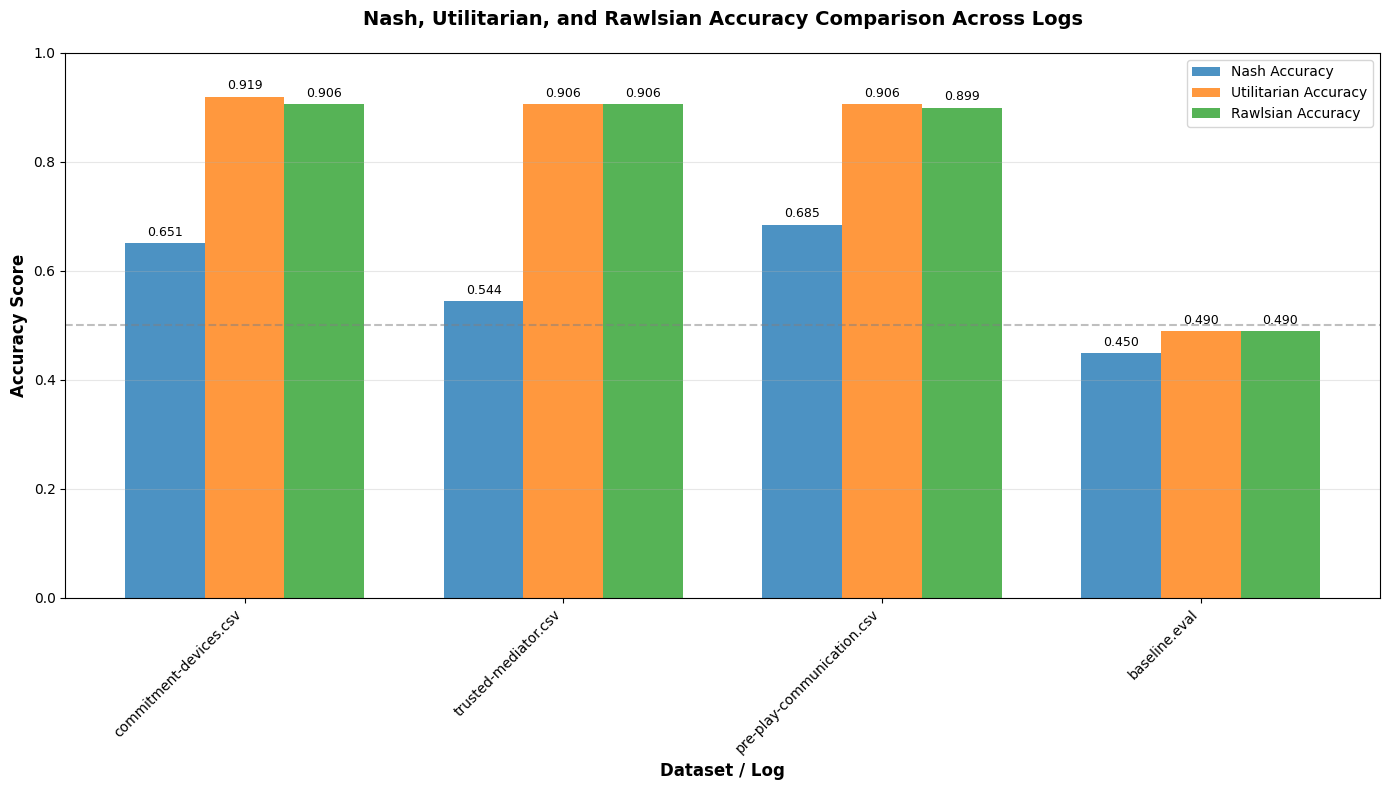


SUMMARY STATISTICS
Dataset                       Nash     Util    Rawls
--------------------------------------------------
commitment-devices.csv       0.651    0.919    0.906
trusted-mediator.csv         0.544    0.906    0.906
pre-play-communication.csv    0.685    0.906    0.899
baseline.eval                0.450    0.490    0.490

Average across all logs:
Average                      0.582    0.805    0.800


In [3]:
def create_score_comparison_plot(results_df):
    """
    Create grouped bar plot comparing Nash, Utilitarian, and Rawlsian accuracies across logs.
    """
    if len(results_df) == 0:
        print("No data to plot!")
        return
    
    # Prepare data for plotting
    datasets = results_df['dataset'].tolist()
    nash_scores = results_df['nash_accuracy'].tolist()
    util_scores = results_df['utilitarian_accuracy'].tolist()
    rawls_scores = results_df['rawlsian_accuracy'].tolist()
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(14, 8))
    
    x = np.arange(len(datasets))
    width = 0.25  # Width of bars
    
    # Colors for the three score types
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, orange, green
    
    # Create bars
    bars1 = ax.bar(x - width, nash_scores, width, label='Nash Accuracy', color=colors[0], alpha=0.8)
    bars2 = ax.bar(x, util_scores, width, label='Utilitarian Accuracy', color=colors[1], alpha=0.8)
    bars3 = ax.bar(x + width, rawls_scores, width, label='Rawlsian Accuracy', color=colors[2], alpha=0.8)
    
    # Add value labels on bars
    def add_value_labels(bars, values):
        for bar, value in zip(bars, values):
            height = bar.get_height()
            ax.annotate(f'{value:.3f}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3),  # 3 points vertical offset
                       textcoords="offset points",
                       ha='center', va='bottom', fontsize=9)
    
    add_value_labels(bars1, nash_scores)
    add_value_labels(bars2, util_scores)
    add_value_labels(bars3, rawls_scores)
    
    # Customize the plot
    ax.set_xlabel('Dataset / Log', fontsize=12, fontweight='bold')
    ax.set_ylabel('Accuracy Score', fontsize=12, fontweight='bold')
    ax.set_title('Nash, Utilitarian, and Rawlsian Accuracy Comparison Across Logs', 
                fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(datasets, rotation=45, ha='right')
    ax.legend()
    ax.set_ylim(0, 1.0)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add horizontal lines for reference
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='50% threshold')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*60)
    print("SUMMARY STATISTICS")
    print("="*60)
    
    print(f"{'Dataset':25s} {'Nash':>8s} {'Util':>8s} {'Rawls':>8s}")
    print("-" * 50)
    
    for _, row in results_df.iterrows():
        print(f"{row['dataset']:25s} {row['nash_accuracy']:8.3f} {row['utilitarian_accuracy']:8.3f} {row['rawlsian_accuracy']:8.3f}")
    
    print("\nAverage across all logs:")
    print(f"{'Average':25s} {results_df['nash_accuracy'].mean():8.3f} {results_df['utilitarian_accuracy'].mean():8.3f} {results_df['rawlsian_accuracy'].mean():8.3f}")

# Create the visualization
create_score_comparison_plot(results_df)

In [4]:
# Additional analysis: Show differences between score types
print("\n" + "="*60)
print("SCORE TYPE ANALYSIS")
print("="*60)

# Calculate differences
results_df['util_vs_nash'] = results_df['utilitarian_accuracy'] - results_df['nash_accuracy']
results_df['rawls_vs_nash'] = results_df['rawlsian_accuracy'] - results_df['nash_accuracy']
results_df['util_vs_rawls'] = results_df['utilitarian_accuracy'] - results_df['rawlsian_accuracy']

print("Differences (positive = first is higher):")
print(f"{'Dataset':25s} {'Util-Nash':>10s} {'Rawls-Nash':>11s} {'Util-Rawls':>11s}")
print("-" * 60)

for _, row in results_df.iterrows():
    print(f"{row['dataset']:25s} {row['util_vs_nash']:10.3f} {row['rawls_vs_nash']:11.3f} {row['util_vs_rawls']:11.3f}")

print("\nAverage differences:")
print(f"{'Average':25s} {results_df['util_vs_nash'].mean():10.3f} {results_df['rawls_vs_nash'].mean():11.3f} {results_df['util_vs_rawls'].mean():11.3f}")

# Show which score type is highest for each log
print("\nHighest scoring approach per log:")
for _, row in results_df.iterrows():
    scores = {
        'Nash': row['nash_accuracy'],
        'Utilitarian': row['utilitarian_accuracy'], 
        'Rawlsian': row['rawlsian_accuracy']
    }
    best_approach = max(scores, key=scores.get)
    best_score = scores[best_approach]
    print(f"  {row['dataset']:25s}: {best_approach} ({best_score:.3f})")


SCORE TYPE ANALYSIS
Differences (positive = first is higher):
Dataset                    Util-Nash  Rawls-Nash  Util-Rawls
------------------------------------------------------------
commitment-devices.csv         0.268       0.255       0.013
trusted-mediator.csv           0.362       0.362       0.000
pre-play-communication.csv      0.221       0.215       0.007
baseline.eval                  0.040       0.040       0.000

Average differences:
Average                        0.223       0.218       0.005

Highest scoring approach per log:
  commitment-devices.csv   : Utilitarian (0.919)
  trusted-mediator.csv     : Utilitarian (0.906)
  pre-play-communication.csv: Utilitarian (0.906)
  baseline.eval            : Utilitarian (0.490)


## Analysis Notes

This notebook compares three different accuracy metrics across evaluation logs:

- **Nash Accuracy**: Proportion of samples where model choices form a Nash equilibrium
- **Utilitarian Accuracy**: Proportion of samples where model choices maximize total welfare (sum of payoffs)
- **Rawlsian Accuracy**: Proportion of samples where model choices maximize the minimum payoff (maximin principle)

The comparison helps understand:
1. Which decision-making principle the model naturally aligns with
2. Whether different datasets/interventions change the model's strategic behavior
3. The relative difficulty of achieving different types of equilibria